In [97]:
print("hello")

hello


In [98]:
import math
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

def f(x):
    return 3*x**2-4*x+5
print(f(3.0))


20.0


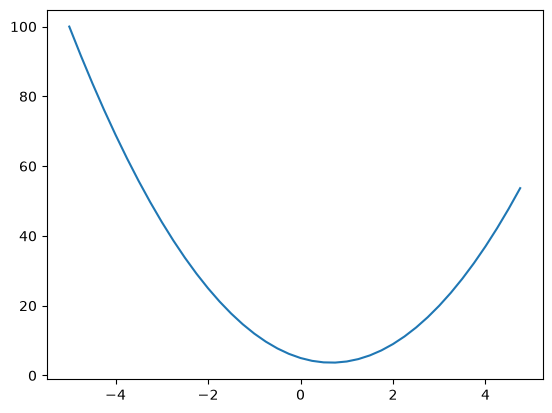

In [99]:
xs=np.arange(-5, 5, 0.25)
ys=f(xs)
plt.plot(xs, ys)

In [100]:
h = 0.000000001
x=3.0
(f(x+h)-f(x))/h

14.000001158365194

In [101]:
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d = a*b + c
print(d)

Value(data=4.0, grad=0.0)


In [102]:
h = 0.0001
a = Value(2.0)
b = Value(-3.0)
c = Value(10.0)
d1 = a*b + c
a+= h 
d2 = a*b + c
print('d1' , d1)
print('d2' , d2)
print('slope' , (d2-d1)/h)
L = (d2-d1)/h


d1 Value(data=4.0, grad=0.0)
d2 Value(data=3.999699999999999, grad=0.0)
slope Value(data=-3.000000000010772, grad=0.0)


In [103]:


class Value:
    def __init__(self, data, _children=(), _op='', label=''):
        self.data = data
        self.grad = 0.0
        self._backward = lambda: None
        self._prev = set(_children)
        self._op = _op
        self.label = label

    def __repr__(self):
        return f"Value(data={self.data}, grad={self.grad})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')
        
        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __radd__(self, other): # Handles scalar + Value (e.g., 2 + a)
        return self + other

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')
        
        def _backward():
            self.grad += other.data * out.grad   # Fixed: Changed = to +=
            other.grad += self.data * out.grad   # Fixed: Changed = to +=
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self * other

    def __pow__(self, other):
        assert isinstance(other, (int, float)), "only supporting int/float powers for now"
        out = Value(self.data**other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __truediv__(self, other):
        return self * (other**-1)

    def __rtruediv__(self, other):
        return Value(other) * (self**-1)

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return Value(other) + (-self)

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Value(t, (self,), 'tanh')
        
        def _backward():
            self.grad += (1 - t**2) * out.grad   # Fixed: Changed = to +=
        out._backward = _backward
        return out

    def exp(self):
        x = self.data
        out = Value(math.exp(x), (self,), 'exp')
        
        def _backward():                          # Fixed: Fixed typo (bacward -> _backward)
            self.grad += out.data * out.grad
        out._backward = _backward                 # Fixed: Correct closure reference
        return out

    def backward(self):
        # Properly indented topological sort
        topo = []
        visited = set()
        
        def build_topo(v):
            if v not in visited:
                visited.add(v)
                for child in v._prev:
                    build_topo(child)
                topo.append(v)
                
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
            node._backward()



In [104]:
d._prev

{Value(data=-6.0, grad=0.0), Value(data=10.0, grad=0.0)}

In [105]:
d._op
a = Value(2.0)
b = Value(4.0)#        other = other if isinstance(other, Value) else Value(other) due to this we can add or multiply here

a+1
a * 2
a.exp()
a / b
a - b


Value(data=-2.0, grad=0.0)

In [106]:
from graphviz import Digraph

def trace(root):
    nodes, edges = set(), set()

    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)

    build(root)
    return nodes, edges


def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        dot.node(
            name=uid,
            label="{ %s| data %.4f | grad %.4f }" % (n.label, n.data, n.grad),
            shape="record"
        )

        if n._op:
            dot.node(name=uid + n._op, label=n._op)
            dot.edge(uid + n._op, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot



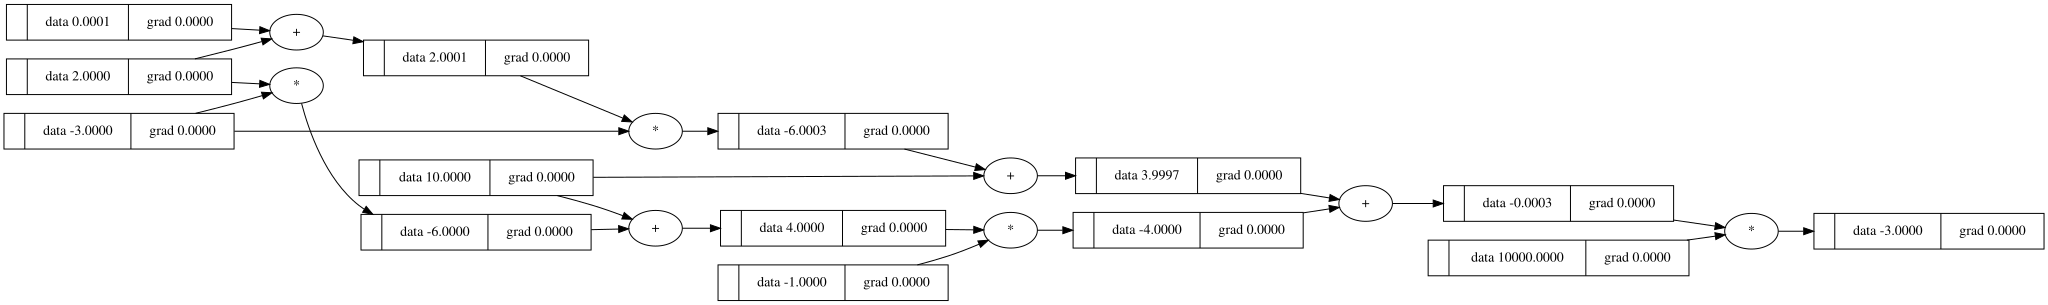

In [107]:
draw_dot(L)

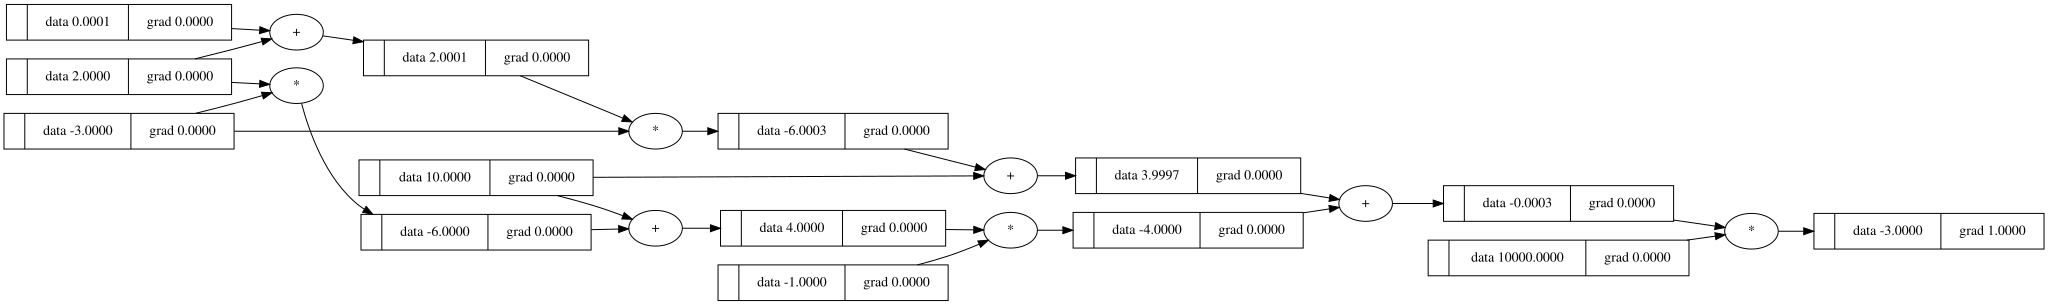

In [108]:
L.grad=1.0#dL/dL=1
draw_dot(L)

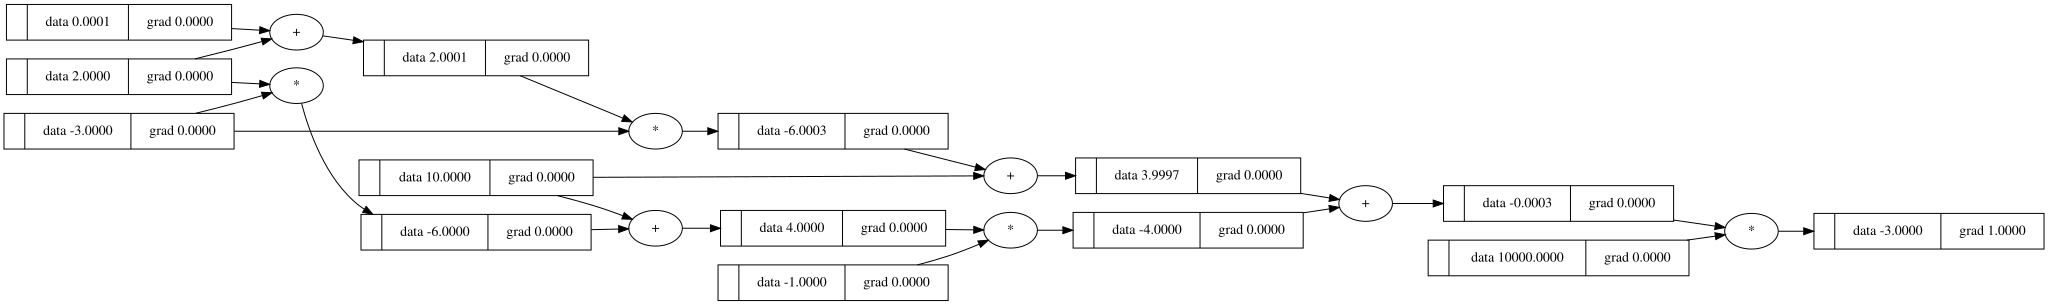

In [109]:
#dL/dF=d as l=f*d and dL/dD=f same logic
f.grad=4.00
d.grad=-2.00
draw_dot(L)


In [110]:
def lol():
    h=0.001
    
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e=a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d*f;L.label='L'
L1=L.data

h=0.001

a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e=a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0+h, label='f')
L = d*f;L.label='L'
L2=L.data

print((L2-L1)/h)  #gradient check



3.9999999999995595


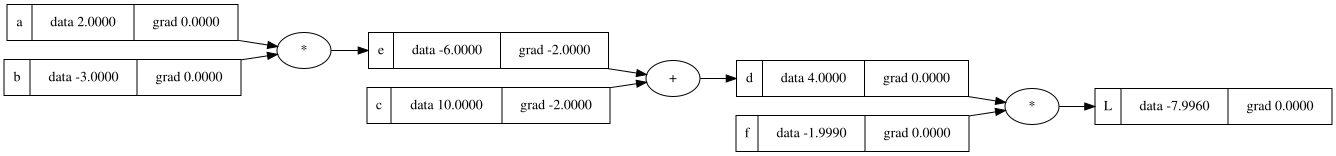

In [111]:
#dd/dc=1.0
#dd/de=1.0 we need dl/dc and dl/de
#we need dL/dc and dL.de  using chain rule we can get both dL/dc=dL/dD*dD/dc and same for other
c.grad=-2.0
e.grad=-2.0
draw_dot(L)

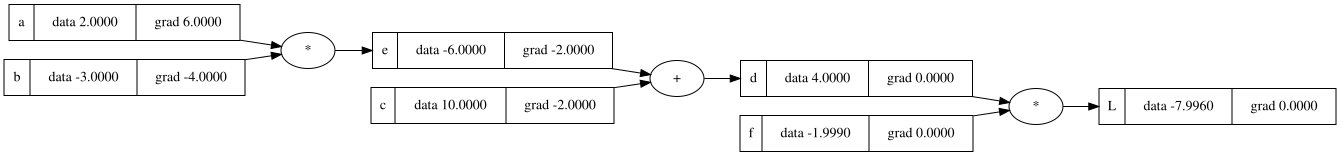

In [112]:
#dL/da=dL/de*de/da and same for dL/db using chain rule
#dL/da=-2*-3=6
#dL/db=-2*2=-4
a.grad=6.0
b.grad=-4.0
draw_dot(L)

In [113]:
a.data+=0.01*a.grad
b.data+=0.01*b.grad
c.data+=0.01*c.grad
f.data+=0.01*f.grad
e=a*b
d=e+c
L=d*f
print(L.data)

-7.4314824


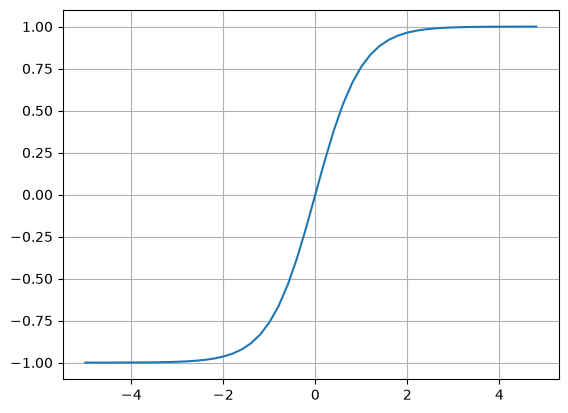

In [114]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2)));plt.grid()


In [115]:
#inputs x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
#weights w1,w2
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
#bias of the neuron
b=Value(6.8813735870195432, label='b')
#x1*w2 +x2*w2
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'




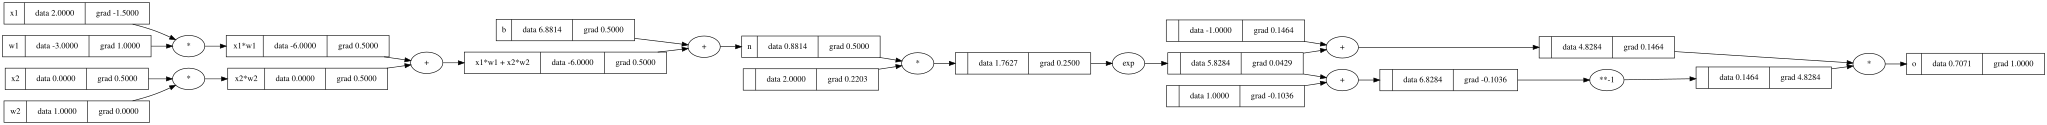

In [116]:
o.grad = 1.0
draw_dot(o)
#inputs x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
#weights w1,w2
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
#bias of the neuron
b=Value(6.8813735870195432, label='b')
#x1*w2 +x2*w2
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e-1) / (e+1)
o.label= 'o'
o.backward()
draw_dot(o)

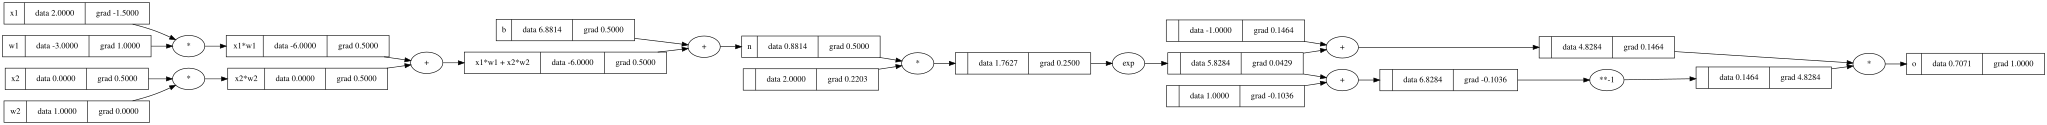

In [117]:
#o = tanhh(n)
#do.dn=1-tanhh(n)^2=1-o**2 value of o=0.707
#do/dn=0.5
n.grad = 0.5
draw_dot(o)

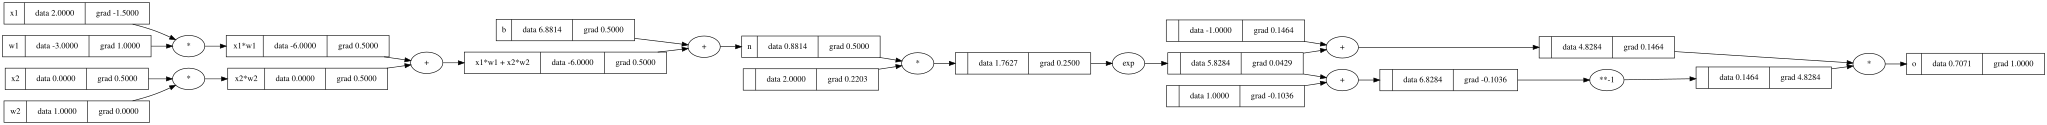

In [118]:
#because of +
#b.grad=x1w1x2w2.grad=0.5
#as there is + sign again 
#x1*w1.grad=x2*w2.grad=0.5
b.grad=0.5
x1w1x2w2.grad=0.5
x1w1.grad=0.5
x2w2.grad=0.5
draw_dot(o)

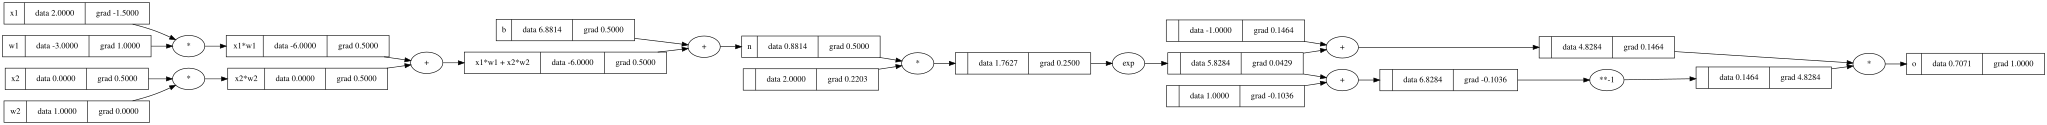

In [119]:
x2.grad = w2.data * x2w2.grad#chain rule
w2.grad = x2.data * x2w2.grad
draw_dot(o)

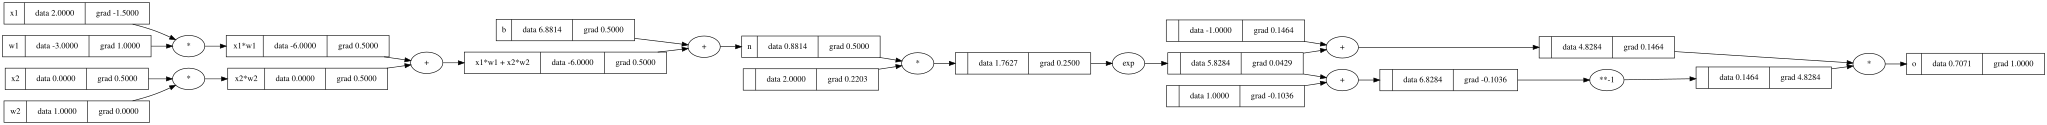

In [120]:
x1.grad = w1.data * x1w1.grad#chain rule
w1.grad = x1.data * x1w1.grad
draw_dot(o)

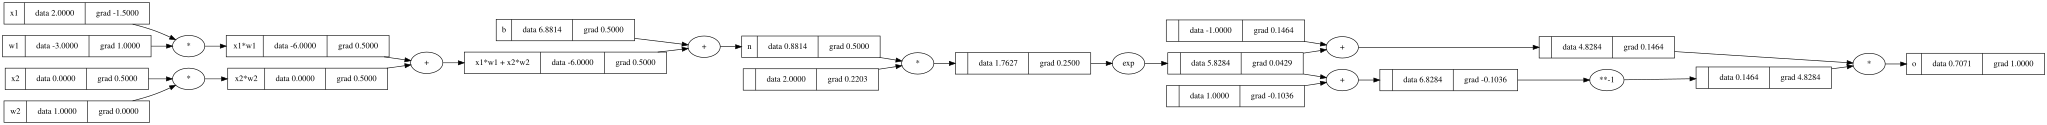

In [121]:
draw_dot(o)

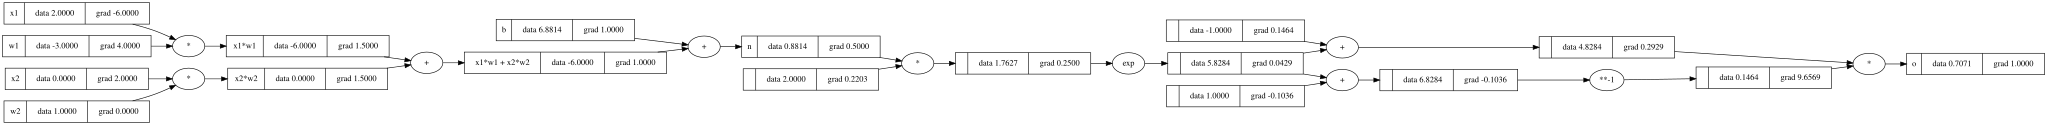

In [122]:
o.grad = 1.0
o._backward()
n._backward()
b._backward()
x1w1x2w2._backward()
x2w2._backward()
x1w1._backward()

draw_dot(o)

In [123]:
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
    build_topo(0)
    topo

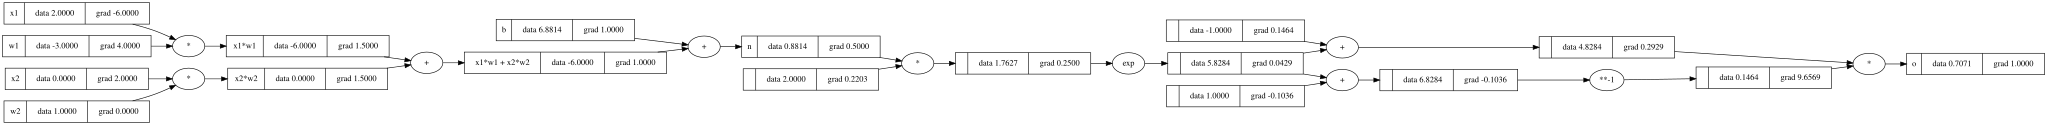

In [124]:
o.grad = 1.0
topo = []
visited = set()
def build_topo(v):
    if v not in visited:
        visited.add(v)
        for child in v._prev:
            build_topo(child)
        topo.append(v)
    build_topo(0)
    for node in reversed(topo):
        node._backward()


draw_dot(o)

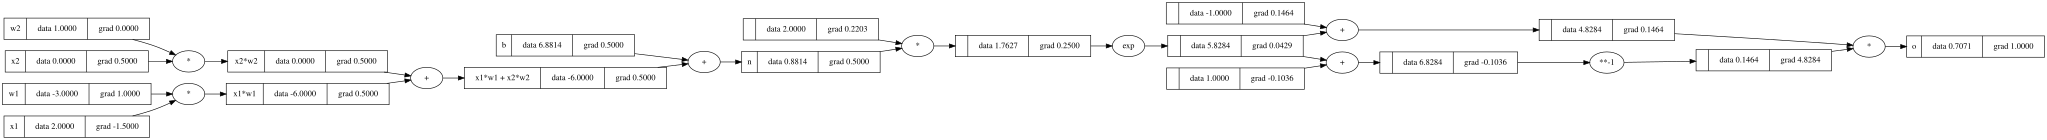

In [125]:
o.grad = 1.0
draw_dot(o)
#inputs x1,x2
x1=Value(2.0, label='x1')
x2=Value(0.0, label='x2')
#weights w1,w2
w1=Value(-3.0, label='w1')
w2=Value(1.0, label='w2')
#bias of the neuron
b=Value(6.8813735870195432, label='b')
#x1*w2 +x2*w2
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
e = (2*n).exp()
o = (e-1) / (e+1)
o.label= 'o'




o.backward()
draw_dot(o)

In [126]:
import torch

In [127]:
import torch
x1 = torch.Tensor([2.0]).double()               ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()               ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()               ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('___')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
___
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


In [128]:
import random
class Neuron:


    def __init__(self,nin):
        self.w = [Value(random.uniform(-1, 1)) for _ in range(nin)]
        self.b = Value(random.uniform(-1,1))

    def __call__(self, x):

        act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
        out = act.tanh()
        return out

    def parameters(self):
        return self.w + [self.b]

class Layer:

    def __init__(self, nin, nout):
        self.neurons = [Neuron(nin) for _ in range(nout)]

    def __call__(self, x):
        outs = [n(x) for n in self.neurons]
        return outs[0] if len(outs)==1 else outs

    def parameters(self):
        return [p for neuron in self.neurons for p in neuron.parameters()]
    

class MLP:

    def __init__(self, nin, nouts):
        sz = [nin] + nouts
        self.layers = [Layer(sz[i], sz[i+1]) for i in range (len(nouts))]


    def __call__(self, x):
        for layer in self.layers:
            x = layer(x)
        return x
    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]
    


In [129]:
x = [2.0, 3.0, -1.0]
n=MLP(3, [4, 4, 1])
n(x)
draw_dot(n(x))
n.parameters()


[Value(data=0.34007825273003833, grad=0.0),
 Value(data=-0.36174119213606604, grad=0.0),
 Value(data=0.7121924804319786, grad=0.0),
 Value(data=-0.4258025065492659, grad=0.0),
 Value(data=0.9658092260588136, grad=0.0),
 Value(data=0.7916787010707727, grad=0.0),
 Value(data=-0.9184994176633487, grad=0.0),
 Value(data=-0.6766693575152507, grad=0.0),
 Value(data=0.9279655915591405, grad=0.0),
 Value(data=-0.5683611456017721, grad=0.0),
 Value(data=-0.47279592842749807, grad=0.0),
 Value(data=0.9861987441928224, grad=0.0),
 Value(data=-0.9398780592694644, grad=0.0),
 Value(data=-0.274731764125945, grad=0.0),
 Value(data=-0.2380756426898838, grad=0.0),
 Value(data=0.4234783929546533, grad=0.0),
 Value(data=-0.4538261892496065, grad=0.0),
 Value(data=0.8968279995223458, grad=0.0),
 Value(data=0.5187585814106881, grad=0.0),
 Value(data=0.6349043863469193, grad=0.0),
 Value(data=-0.7536570196021914, grad=0.0),
 Value(data=-0.7708463971210799, grad=0.0),
 Value(data=0.4685697913306348, grad=0.0

In [136]:
ypred = [n(x) for x in xs]

In [137]:
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss

Value(data=7.772546544816929, grad=0.0)

In [138]:
loss.backward()
n.layers[0].neurons[0].w[0].grad

-0.30837354133525985

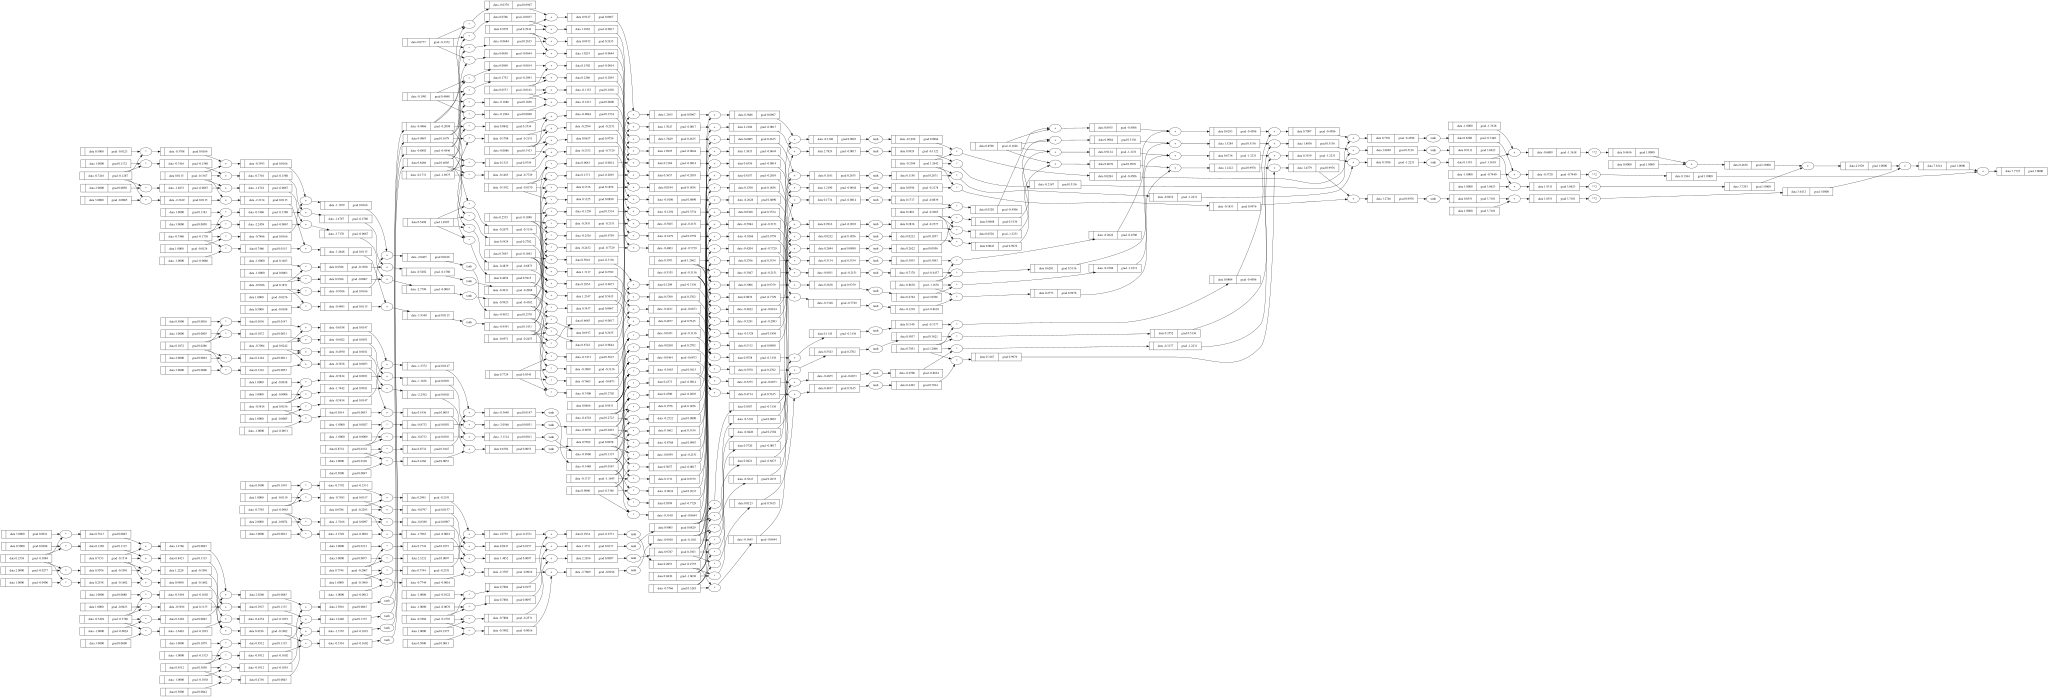

In [139]:
draw_dot(loss)


In [140]:
n.layers[0].neurons[0].w[0].data
xs = [[2.0, 3.0, -1.0],
     [3.0, -1.0, 0.5],
     [0.5, 1.0, 1.0],
     [1.0, 1.0, -1.0],]


ys = [1.0, -1.0, -1.0, 1.0]
n = MLP(3, [4,4,1])


In [ ]:
ypred = [n(x) for x in xs]
loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))
loss
    



Value(data=7.999999591003956, grad=0.0)

In [141]:
for k in range(20):

    ypred = [n(x) for x in xs]
    loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred))

    for p in n.parameters():
        p.grad = 0.0


    loss.backward()

    for p in n.parameters():
        p.data+= -0.05 * p.grad

    print(k, loss.data)

0 6.2184853879635105
1 2.0506310395362837
2 0.5645472713217838
3 0.28068940713551194
4 0.19260532120964194
5 0.1462373828386757
6 0.11765951549601694
7 0.09830429740715466
8 0.0843411007528233
9 0.07380037829049958
10 0.0655662828417124
11 0.058959639335924324
12 0.05354355254778166
13 0.049024326901460344
14 0.045197306728679776
15 0.04191555289511886
16 0.03907086376271057
17 0.03658181713275969
18 0.03438598046265097
19 0.032434688238150294


In [ ]:
ypred

[Value(data=1.0, grad=0.0),
 Value(data=1.0, grad=4.0),
 Value(data=1.0, grad=4.0),
 Value(data=1.0, grad=0.0)]

In [ ]:
loss.backward()


In [ ]:
n.layers[0].neurons[0].w[0].grad

-15.138516551401242

In [ ]:
n.layers[0].neurons[0].w[0].data

2.988540510353431

In [ ]:
for p in n.parameters():
    p.data += -0.05* p.grad

In [ ]:
ypred

[Value(data=0.9999999901848412, grad=-1.963031759366629e-08),
 Value(data=0.999999907659138, grad=3.999999815318276),
 Value(data=0.9999999900918489, grad=3.9999999801836976),
 Value(data=0.9999999850132797, grad=-2.997344061839158e-08)]

In [ ]:
n.parameters()

[Value(data=3.1399256758674436, grad=-15.138516551401242),
 Value(data=-0.4547564795314807, grad=1.1245218122073026),
 Value(data=2.389073924655835, grad=-7.062612291409447),
 Value(data=1.2272562022076203, grad=-8.486315421106756),
 Value(data=-2.6119080145255973, grad=11.251962996825391),
 Value(data=-1.8082540727279848, grad=11.927013478152093),
 Value(data=2.8817600115795026, grad=-16.073739798543652),
 Value(data=-2.538212363624154, grad=7.81340988859353),
 Value(data=-1.0345429804363475, grad=9.146611486628235),
 Value(data=-3.2501657280039296, grad=13.501172821853766),
 Value(data=0.7821916599383683, grad=-7.003769946282811),
 Value(data=-2.006381977530418, grad=5.352910888102172),
 Value(data=-1.0789217861283493, grad=5.301526045672974),
 Value(data=-2.8179971737986773, grad=10.946236014983198),
 Value(data=0.5257858935174835, grad=-4.909323437620927),
 Value(data=0.050208262980983236, grad=3.5579587070486007),
 Value(data=3.935102209617175, grad=-14.19433906038472),
 Value(dat